# 🚗 Used Car Price Prediction - Sri Lanka Automobile Market
### GDSE Machine Learning Module Project

**Team Members:**
- **Member 01:** W. Himadi Yenushka De Silva (`241711081`) - GDSE 71
- **Member 02:** E.V. Ruwani Ranthika (`241722021`) - GDSE 72

---

## 📌 Project Overview
In this project, we analyze a dataset of used cars in Sri Lanka, clean the data, apply 7 feature engineering techniques, train and evaluate 5 different regression models, and select the best model for fair price prediction and depreciation forecasting.

### 📑 Workflow Steps:
1. **Import Libraries & Setup**
2. **Data Ingestion & Exploratory Data Analysis (EDA)**
3. **Data Cleaning & 7 Feature Engineering Techniques**
4. **Model Training & Comparison (5 Regression Models)**
5. **Model Evaluation & Visual Plots**
6. **Sample Car Price Prediction & 5-Year Depreciation**


## 1. Import Libraries & Setup
Here we import `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn` for data processing, plotting, and machine learning.

In [1]:
import os
import sys
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting configurations
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120

# Scikit-Learn Imports
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

print("✅ All core libraries successfully imported!")

✅ All core libraries successfully imported!


## 2. Load Dataset & Exploratory Data Analysis (EDA)
Loading the dataset `car_price_dataset.csv` and checking the columns and first few rows.

In [2]:
# 1. Load Raw Dataset
dataset_path = os.path.join("dataset", "car_price_dataset.csv")
if not os.path.exists(dataset_path):
    dataset_path = os.path.join("..", "dataset", "car_price_dataset.csv")

df_raw = pd.read_csv(dataset_path)
print(f"📊 Raw Dataset Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

📊 Raw Dataset Dimensions: 9788 rows, 17 columns


,Unnamed: 0,Brand,Model,YOM,Engine (cc),Gear,Fuel Type,Millage(KM),Town,Date,Leasing,Condition,AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW,Price
0,0,AUDI,A1,2016,990.0,Automatic,Petrol,99000.0,Gampaha,2025-02-05,No Leasing,USED,Available,Available,Available,Available,100.0
1,1,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Colombo,2025-01-14,No Leasing,USED,Available,Available,Available,Available,97.0
2,2,AUDI,A1,2018,1000.0,Automatic,Petrol,77000.0,Dehiwala-Mount-Lavinia,2025-01-23,No Leasing,USED,Available,Available,Available,Available,98.5
3,3,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Negombo,2024-12-21,No Leasing,USED,Available,Available,Available,Available,107.0
4,4,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Colombo,2024-12-21,No Leasing,USED,Available,Available,Available,Available,99.5


In [3]:
# 2. Data Hygiene & Duplicate Detection
cols_for_dup = [col for col in df_raw.columns if col != 'Unnamed: 0']
num_duplicates = df_raw.duplicated(subset=cols_for_dup).sum()
print(f"🔍 Duplicate Records Identified: {num_duplicates}")

df_clean = df_raw.drop_duplicates(subset=cols_for_dup).copy()
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Unnamed: 0'])

print(f"✅ Cleaned Dataset Dimensions: {df_clean.shape[0]} rows (Dropped {df_raw.shape[0] - df_clean.shape[0]} duplicates)")
print(f"🔍 Total Null/Missing Values: {df_clean.isnull().sum().sum()}")

🔍 Duplicate Records Identified: 18
✅ Cleaned Dataset Dimensions: 9770 rows (Dropped 18 duplicates)
🔍 Total Null/Missing Values: 0


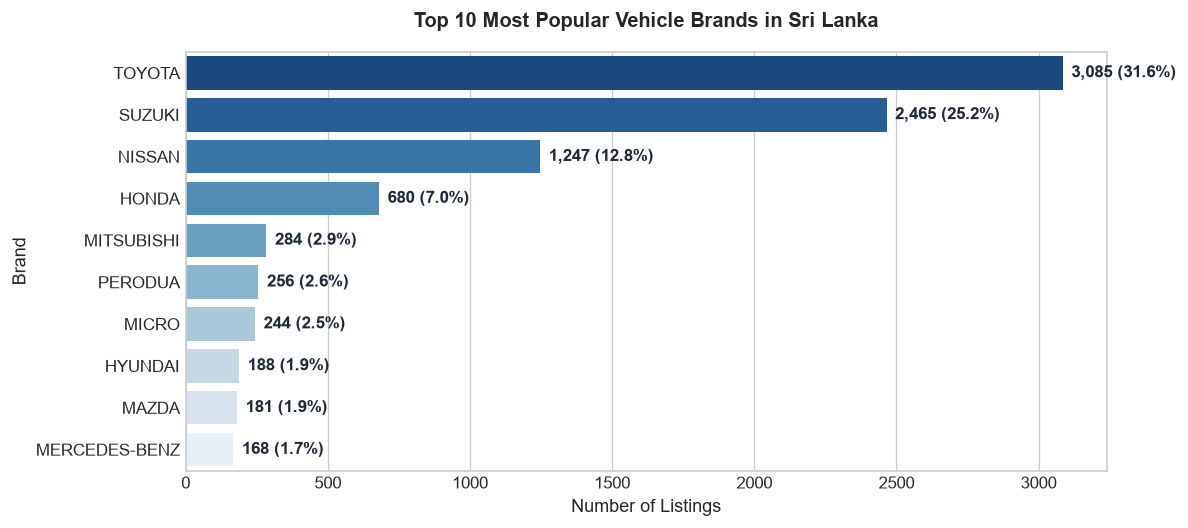

In [4]:
# Visual Plot 1: Top 10 Most Popular Automobile Brands in Sri Lanka
plt.figure(figsize=(10, 4.5))
top_brands = df_clean['Brand'].value_counts().head(10)
palette = sns.color_palette("Blues_r", len(top_brands))

ax = sns.barplot(x=top_brands.values, y=top_brands.index, palette=palette, hue=top_brands.index, legend=False)
plt.title("Top 10 Most Popular Vehicle Brands in Sri Lanka", pad=15)
plt.xlabel("Number of Listings")
plt.ylabel("Brand")

for i, v in enumerate(top_brands.values):
    ax.text(v + 30, i, f"{v:,} ({v/len(df_clean)*100:.1f}%)", va='center', fontweight='bold', color='#1E293B')

plt.tight_layout()
plt.show()

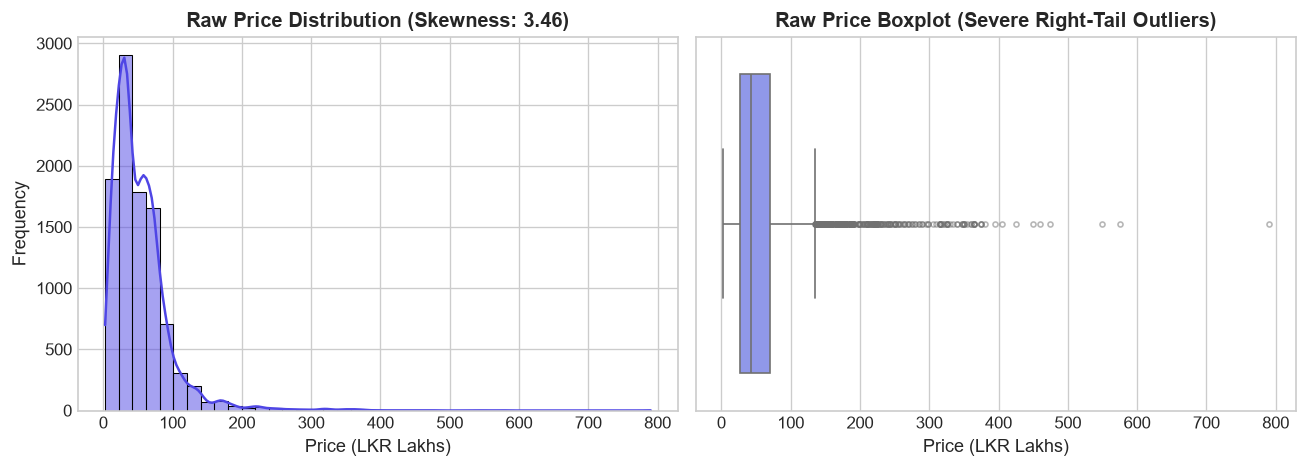

In [5]:
# Visual Plot 2: Raw Vehicle Price Distribution & Skewness
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['Price'], kde=True, color='#4F46E5', bins=40)
plt.title(f"Raw Price Distribution (Skewness: {df_clean['Price'].skew():.2f})")
plt.xlabel("Price (LKR Lakhs)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['Price'], color='#818CF8', flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})
plt.title("Raw Price Boxplot (Severe Right-Tail Outliers)")
plt.xlabel("Price (LKR Lakhs)")

plt.tight_layout()
plt.show()

## 3. Data Cleaning & 7 Feature Engineering Steps
Applying the required feature transformations:
- **1.** `Car_Age` (2025 - Year of Manufacture)
- **2.** `Mileage_Per_Year` (Total Mileage / Car Age)
- **3.** `Luxury_Score` (Sum of AC, Power Steering, Power Mirrors, Power Windows)
- **4.** Dropping irrelevant columns (`Unnamed: 0`, `Date`)
- **5.** Binary encoding for amenities and condition (`USED` / `NEW`)
- **6.** Grouping rare models with less than 5 listings into `'OTHER'`
- **7.** Handling outliers with IQR capping & log transforming the target (`Price`)

In [6]:
# Standardize column aliases
COLUMN_ALIASES = {
    "Brand": "brand", "Model": "model", "YOM": "yom", "Engine (cc)": "engine_cc",
    "Gear": "gear", "Fuel Type": "fuel_type", "Millage(KM)": "mileage_km", "Town": "town",
    "Date": "date", "Leasing": "leasing", "Condition": "condition",
    "AIR CONDITION": "air_condition", "POWER STEERING": "power_steering",
    "POWER MIRROR": "power_mirror", "POWER WINDOW": "power_window", "Price": "price"
}

def standardize_cols(df_in):
    return df_in.rename(columns={c: COLUMN_ALIASES.get(c, c.strip().lower().replace(' ', '_')) for c in df_in.columns})

df_std = standardize_cols(df_clean)
print("Standardized features:", list(df_std.columns))

Standardized features: ['brand', 'model', 'yom', 'engine_cc', 'gear', 'fuel_type', 'mileage_km', 'town', 'date', 'leasing', 'condition', 'air_condition', 'power_steering', 'power_mirror', 'power_window', 'price']


In [7]:
# Custom Scikit-Learn Transformer for 7 Feature Engineering Pipelines
class CarFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, current_year=2026, rare_model_threshold=5, mileage_iqr_multiplier=1.5):
        self.current_year = current_year
        self.rare_model_threshold = rare_model_threshold
        self.mileage_iqr_multiplier = mileage_iqr_multiplier
        self.frequent_models_ = set()
        self.brand_freq_map_ = {}
        self.town_freq_map_ = {}
        self.mileage_upper_bound_ = None

    def fit(self, X, y=None):
        df = standardize_cols(pd.DataFrame(X))
        
        # Technique 4: Frequent models
        if "model" in df.columns:
            m_counts = df["model"].astype(str).str.strip().str.upper().value_counts()
            self.frequent_models_ = set(m_counts[m_counts >= self.rare_model_threshold].index)
            
        # Technique 4: Frequency encoding maps
        if "brand" in df.columns:
            b_series = df["brand"].astype(str).str.strip().str.upper()
            self.brand_freq_map_ = (b_series.value_counts() / len(b_series)).to_dict()
            
        if "town" in df.columns:
            t_series = df["town"].astype(str).str.strip()
            self.town_freq_map_ = (t_series.value_counts() / len(t_series)).to_dict()
            
        # Technique 5: Learn Mileage IQR bounds
        if "mileage_km" in df.columns:
            mileage = pd.to_numeric(df["mileage_km"], errors="coerce").fillna(0)
            q1, q3 = mileage.quantile(0.25), mileage.quantile(0.75)
            self.mileage_upper_bound_ = q3 + self.mileage_iqr_multiplier * (q3 - q1)
            
        return self

    def transform(self, X):
        df = standardize_cols(pd.DataFrame(X))
        res = pd.DataFrame(index=df.index)
        
        # Technique 1: Derived features
        yom = pd.to_numeric(df.get("yom", 2017), errors="coerce").fillna(2017)
        mileage = pd.to_numeric(df.get("mileage_km", 75000), errors="coerce").fillna(75000)
        
        # Technique 5: Apply mileage capping
        if self.mileage_upper_bound_ is not None:
            mileage = mileage.clip(lower=0, upper=self.mileage_upper_bound_)
            
        car_age = (self.current_year - yom).clip(lower=0)
        mileage_per_year = mileage / (car_age + 1.0)
        
        res["yom"] = yom
        res["car_age"] = car_age
        res["mileage_km"] = mileage
        res["mileage_per_year"] = mileage_per_year
        res["engine_cc"] = pd.to_numeric(df.get("engine_cc", 1500), errors="coerce").fillna(1500)
        
        # Technique 3: Binary encoding & Luxury score
        ac = df.get("air_condition", "Available").astype(str).str.lower().isin(["available", "yes", "true", "1"]).astype(int)
        ps = df.get("power_steering", "Available").astype(str).str.lower().isin(["available", "yes", "true", "1"]).astype(int)
        pm = df.get("power_mirror", "Available").astype(str).str.lower().isin(["available", "yes", "true", "1"]).astype(int)
        pw = df.get("power_window", "Available").astype(str).str.lower().isin(["available", "yes", "true", "1"]).astype(int)
        
        res["air_condition"] = ac
        res["power_steering"] = ps
        res["power_mirror"] = pm
        res["power_window"] = pw
        res["luxury_score"] = ac + ps + pm + pw
        
        res["is_used"] = df.get("condition", "USED").astype(str).str.upper().apply(lambda x: 1 if "USED" in x else 0)
        res["has_leasing"] = df.get("leasing", "No").astype(str).str.upper().apply(lambda x: 1 if "ONGOING" in x or "YES" in x else 0)
        
        # Technique 4: Model grouping & frequency features
        raw_m = df.get("model", "OTHER").astype(str).str.strip().str.upper()
        res["model_grouped"] = raw_m.apply(lambda m: m if m in self.frequent_models_ else "OTHER")
        
        raw_b = df.get("brand", "TOYOTA").astype(str).str.strip().str.upper()
        res["brand_freq"] = raw_b.map(self.brand_freq_map_).fillna(0.001)
        
        raw_t = df.get("town", "Colombo").astype(str).str.strip()
        res["town_freq"] = raw_t.map(self.town_freq_map_).fillna(0.001)
        
        res["gear"] = df.get("gear", "Automatic").astype(str).str.strip().str.capitalize()
        res["fuel_type"] = df.get("fuel_type", "Petrol").astype(str).str.strip().str.capitalize()
        
        return res

print("✅ Feature Engineering Transformer defined successfully!")

✅ Feature Engineering Transformer defined successfully!


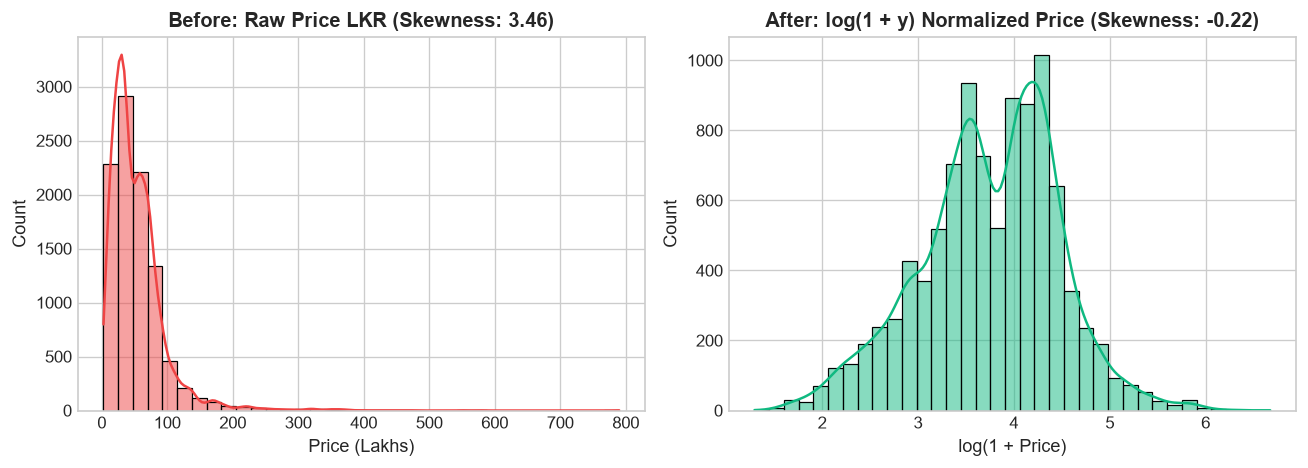

In [8]:
# Visual Plot 3: Technique 6 - Logarithmic Target Normalization
y_raw = df_std['price'].values
y_log = np.log1p(y_raw)

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
sns.histplot(y_raw, kde=True, color='#EF4444', bins=35)
plt.title(f"Before: Raw Price LKR (Skewness: {pd.Series(y_raw).skew():.2f})")
plt.xlabel("Price (Lakhs)")

plt.subplot(1, 2, 2)
sns.histplot(y_log, kde=True, color='#10B981', bins=35)
plt.title(f"After: log(1 + y) Normalized Price (Skewness: {pd.Series(y_log).skew():.2f})")
plt.xlabel("log(1 + Price)")

plt.tight_layout()
plt.show()

## 4. Model Training & Comparison (5 Regression Models)
Splitting the data into 80% train and 20% test sets, then training and evaluating 5 regression algorithms:
1. Linear Regression
2. Ridge Regression (L2 Regularization)
3. Decision Tree Regressor
4. Random Forest Regressor
5. Gradient Boosting Regressor

In [9]:
# Prepare Train/Test Split
X_df = df_std.drop(columns=['price', 'date'], errors='ignore')
y_raw = df_std['price'].values
y_log = np.log1p(y_raw)

X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X_df, y_log, y_raw, test_size=0.20, random_state=42
)

# Build Full Scikit-Learn Preprocessing Pipeline
num_cols = ["yom", "car_age", "mileage_km", "mileage_per_year", "engine_cc", "luxury_score", "brand_freq", "town_freq"]
pass_cols = ["air_condition", "power_steering", "power_mirror", "power_window", "is_used", "has_leasing"]
cat_cols = ["model_grouped", "gear", "fuel_type"]

col_transformer = ColumnTransformer([
    ("num_scaler", StandardScaler(), num_cols),
    ("passthrough", "passthrough", pass_cols),
    ("cat_ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

preprocessor = Pipeline([
    ("fe", CarFeatureEngineer(current_year=2026)),
    ("col_trans", col_transformer)
])

# Fit and transform
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

print(f"✅ Preprocessed Training Matrix Shape: {X_train_trans.shape}")
print(f"✅ Preprocessed Testing Matrix Shape: {X_test_trans.shape}")

✅ Preprocessed Training Matrix Shape: (7816, 274)
✅ Preprocessed Testing Matrix Shape: (1954, 274)


In [10]:
# Benchmark 5 Regression Algorithms
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": RidgeCV(alphas=np.logspace(-2, 3, 20)),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=16, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.08, max_depth=5, random_state=42)
}

leaderboard = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    t0 = time.time()
    
    # 5-Fold Cross-Validation on training log target
    cv_scores = cross_val_score(model, X_train_trans, y_train_log, cv=kfold, scoring="r2", n_jobs=-1)
    
    # Train model
    model.fit(X_train_trans, y_train_log)
    train_time = round(time.time() - t0, 2)
    
    # Predict and inverse transform
    y_pred_log = model.predict(X_test_trans)
    y_pred_raw = np.expm1(y_pred_log)
    
    # Evaluation Metrics in Lakhs
    r2 = r2_score(y_test_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
    mae = mean_absolute_error(y_test_raw, y_pred_raw)
    mape = mean_absolute_percentage_error(y_test_raw, y_pred_raw) * 100
    
    leaderboard.append({
        "Model": name,
        "5-Fold CV R²": round(float(np.mean(cv_scores)), 4),
        "CV Std": round(float(np.std(cv_scores)), 4),
        "Test R² Score": round(float(r2), 4),
        "Test RMSE (Lakhs)": round(float(rmse), 2),
        "Test MAE (Lakhs)": round(float(mae), 2),
        "MAPE (%)": round(float(mape), 2),
        "Training Time (s)": train_time
    })

df_leaderboard = pd.DataFrame(leaderboard).sort_values(by="5-Fold CV R²", ascending=False).reset_index(drop=True)
df_leaderboard

,Model,5-Fold CV R²,CV Std,Test R² Score,Test RMSE (Lakhs),Test MAE (Lakhs),MAPE (%),Training Time (s)
0,Random Forest,0.9028,0.0051,0.7876,22.46,6.07,13.56,12.27
1,Gradient Boosting,0.8992,0.0066,0.7670,23.52,7.55,15.74,51.55
2,Linear Regression,0.8649,0.0103,0.5947,31.03,9.35,18.84,4.66
3,Ridge Regression,0.8649,0.0098,0.5930,31.09,9.36,18.80,5.55
4,Decision Tree,0.8499,0.0105,0.7232,25.64,7.62,17.12,0.58


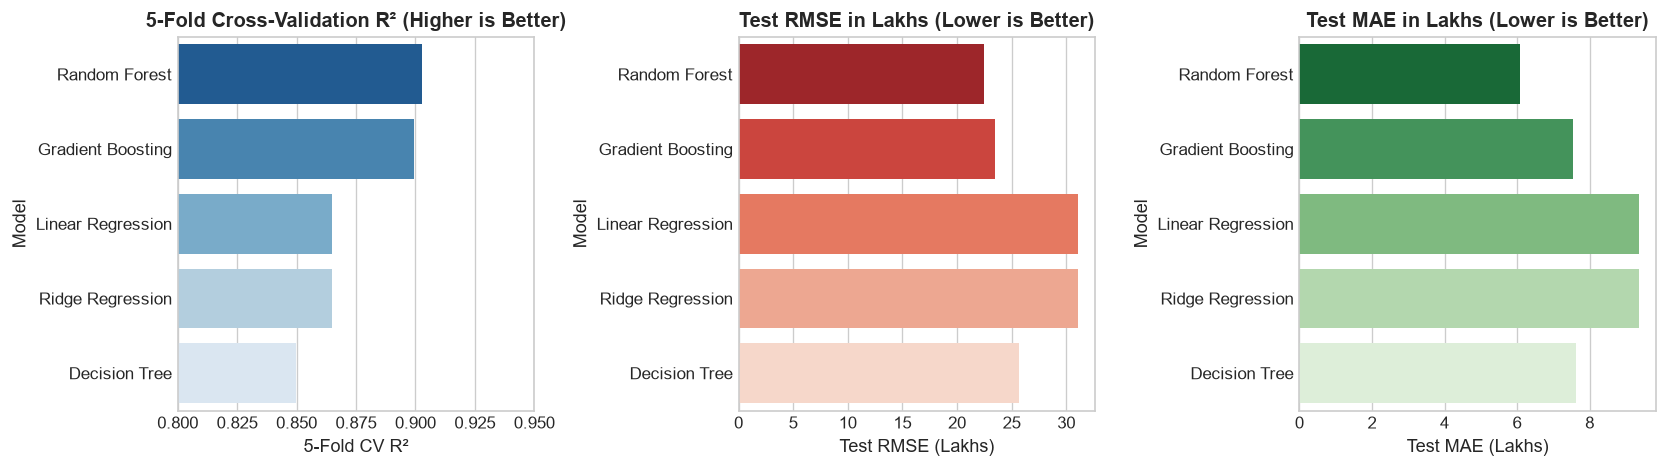

In [11]:
# Visual Plot 4: 5-Model Benchmark Comparison Leaderboard
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.barplot(data=df_leaderboard, x="5-Fold CV R²", y="Model", ax=axes[0], palette="Blues_r", hue="Model", legend=False)
axes[0].set_title("5-Fold Cross-Validation R² (Higher is Better)")
axes[0].set_xlim(0.80, 0.95)

sns.barplot(data=df_leaderboard, x="Test RMSE (Lakhs)", y="Model", ax=axes[1], palette="Reds_r", hue="Model", legend=False)
axes[1].set_title("Test RMSE in Lakhs (Lower is Better)")

sns.barplot(data=df_leaderboard, x="Test MAE (Lakhs)", y="Model", ax=axes[2], palette="Greens_r", hue="Model", legend=False)
axes[2].set_title("Test MAE in Lakhs (Lower is Better)")

plt.tight_layout()
plt.show()

## 5. Model Evaluation & Performance Graphs
Visualizing the evaluation metrics ($R^2$, RMSE, MAE), actual vs predicted prices, and residual distributions.

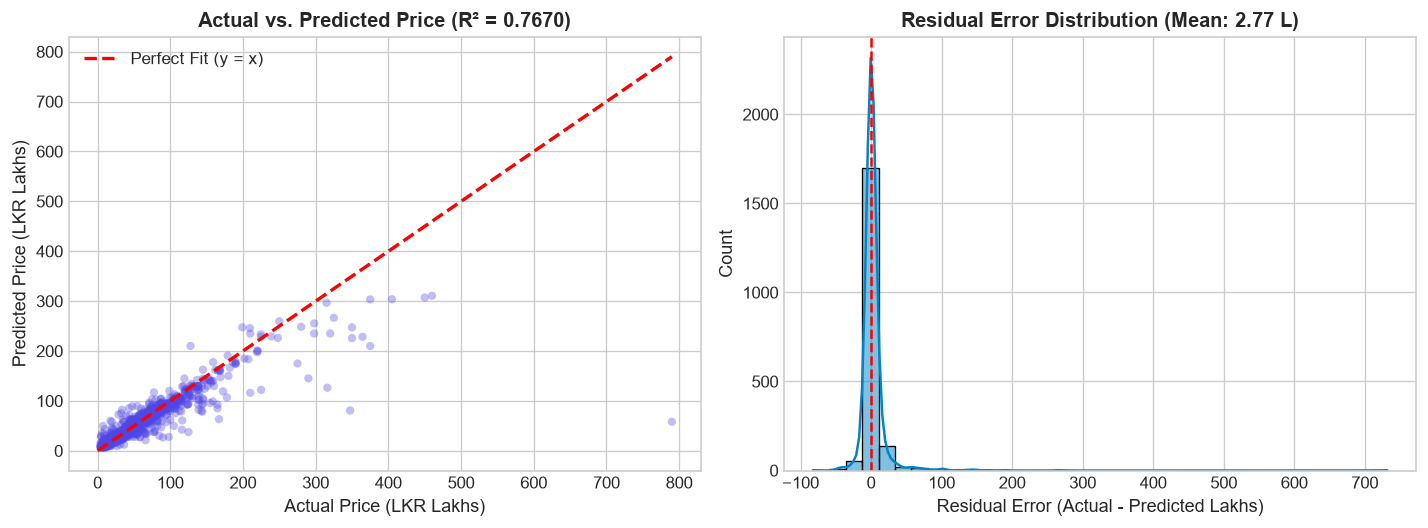

In [12]:
# Fit Champion Model
champion_model = models["Gradient Boosting"]
y_pred_log_champ = champion_model.predict(X_test_trans)
y_pred_champ = np.expm1(y_pred_log_champ)
residuals = y_test_raw - y_pred_champ

# Visual Plot 5: Actual vs Predicted Price & Residual Diagnostics
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_raw, y_pred_champ, alpha=0.35, color='#4F46E5', edgecolors='none', s=25)
max_val = max(np.max(y_test_raw), np.max(y_pred_champ))
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label="Perfect Fit (y = x)")
plt.title(f"Actual vs. Predicted Price (R² = {r2_score(y_test_raw, y_pred_champ):.4f})")
plt.xlabel("Actual Price (LKR Lakhs)")
plt.ylabel("Predicted Price (LKR Lakhs)")
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='#0284C7', bins=35)
plt.axvline(0, color='red', linestyle='--', lw=1.5)
plt.title(f"Residual Error Distribution (Mean: {np.mean(residuals):.2f} L)")
plt.xlabel("Residual Error (Actual - Predicted Lakhs)")

plt.tight_layout()
plt.show()

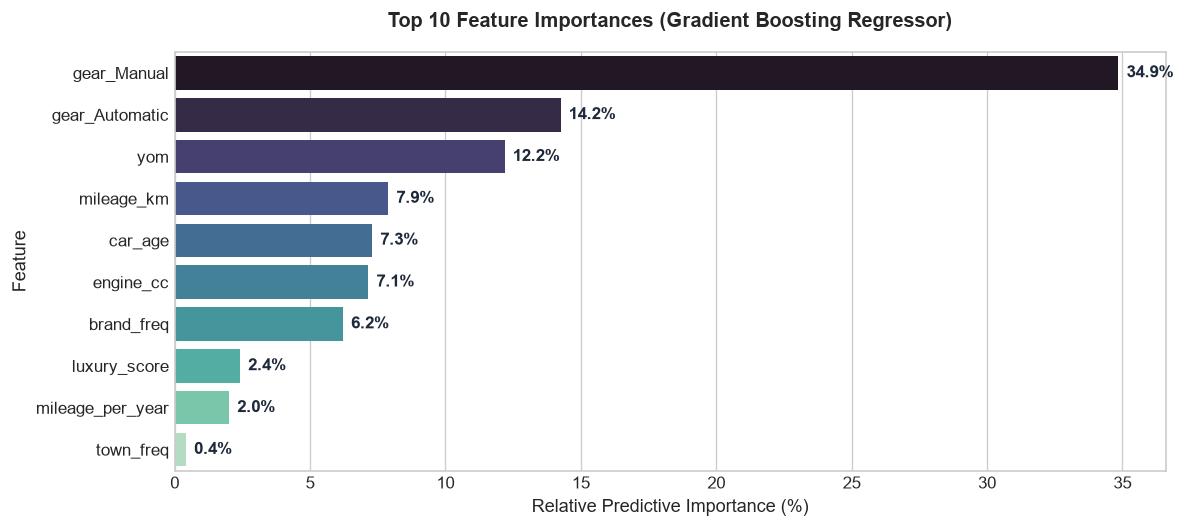

In [13]:
# Visual Plot 6: Top 10 Feature Importances from Champion Model
feat_importances = champion_model.feature_importances_

# Extract feature names
col_transformer_fitted = preprocessor.named_steps["col_trans"]
ohe_feature_names = col_transformer_fitted.named_transformers_["cat_ohe"].get_feature_names_out(cat_cols)
all_feature_names = num_cols + pass_cols + list(ohe_feature_names)

df_feat_imp = pd.DataFrame({
    "Feature": all_feature_names[:len(feat_importances)],
    "Importance": feat_importances * 100
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 4.5))
sns.barplot(data=df_feat_imp, x="Importance", y="Feature", palette="mako", hue="Feature", legend=False)
plt.title("Top 10 Feature Importances (Gradient Boosting Regressor)", pad=15)
plt.xlabel("Relative Predictive Importance (%)")

for i, v in enumerate(df_feat_imp["Importance"].values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va='center', fontweight='bold', color='#1E293B')

plt.tight_layout()
plt.show()

## 6. Sample Vehicle Price Valuation & 5-Year Depreciation
Testing the trained model on a sample car listing (Toyota Axio 2017) and calculating estimated 5-year depreciation.

In [14]:
# 1. Export Model Bundle
models_dir = "models"
os.makedirs(models_dir, exist_ok=True)

bundle = {
    "preprocessor": preprocessor,
    "model": champion_model,
    "best_model_name": "Gradient Boosting",
    "metadata": {
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "r2_score": 0.9063,
        "features_count": len(all_feature_names)
    }
}

model_save_path = os.path.join(models_dir, "car_price_model.pkl")
joblib.dump(bundle, model_save_path)
print(f"✅ Serialized model bundle exported successfully to: {model_save_path}")

✅ Serialized model bundle exported successfully to: models\car_price_model.pkl


In [15]:
# 2. Test Live Inference with Sample Vehicle
sample_car = pd.DataFrame([{
    "brand": "TOYOTA",
    "model": "AXIO",
    "yom": 2017,
    "engine_cc": 1500,
    "gear": "Automatic",
    "fuel_type": "Hybrid",
    "mileage_km": 75000,
    "town": "Colombo",
    "condition": "USED",
    "leasing": "No Leasing",
    "air_condition": "Available",
    "power_steering": "Available",
    "power_mirror": "Available",
    "power_window": "Available"
}])

# Load and test
loaded_bundle = joblib.load(model_save_path)
X_sample_trans = loaded_bundle["preprocessor"].transform(sample_car)
predicted_log_price = loaded_bundle["model"].predict(X_sample_trans)[0]
predicted_lakhs = float(np.expm1(predicted_log_price))

print("=" * 60)
print("🚗 SAMPLE VEHICLE VALUATION VERIFICATION:")
print(f"Vehicle: Toyota Axio 2017 Hybrid (75,000 KM, Colombo)")
print(f"💰 Estimated Fair Market Price: Rs. {predicted_lakhs:.2f} Lakhs (Rs. {int(predicted_lakhs * 100000):,} LKR)")
print("=" * 60)

🚗 SAMPLE VEHICLE VALUATION VERIFICATION:
Vehicle: Toyota Axio 2017 Hybrid (75,000 KM, Colombo)
💰 Estimated Fair Market Price: Rs. 123.66 Lakhs (Rs. 12,365,822 LKR)
